## Note
1) Ensemblement techniques can work decently good even in imbalanced datasets.

# Context

"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

#### Dataset Source: https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("./Travel.xls")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [2]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

 ### Data Cleaning
 #### Handling 
 1) missing values
 2) duplicates
 3) check data type
 4) Understand the dataset

In [3]:
# checking of categories
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [4]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [5]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64

In [7]:
# Checking of missing values count in each column
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [8]:
df.isnull().mean()*100 # just checking the mean values, optional


CustomerID                  0.000000
ProdTaken                   0.000000
Age                         4.623568
TypeofContact               0.511457
CityTier                    0.000000
DurationOfPitch             5.135025
Occupation                  0.000000
Gender                      0.000000
NumberOfPersonVisiting      0.000000
NumberOfFollowups           0.920622
ProductPitched              0.000000
PreferredPropertyStar       0.531915
MaritalStatus               0.000000
NumberOfTrips               2.864157
Passport                    0.000000
PitchSatisfactionScore      0.000000
OwnCar                      0.000000
NumberOfChildrenVisiting    1.350245
Designation                 0.000000
MonthlyIncome               4.766776
dtype: float64

In [9]:
# fix for missing values
 # take previous function df.is_null().sum() and find where it is having at least 1 null value
# features_with_na = [features for features in df.columns]
# print(features_with_na)
# next add if condition to output only columns with at least 1 null value
features_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
print(features_with_na)


['Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']


In [10]:
# next we want the percentage of missing value
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,2),'% of missing values')
    # mean = add all values (0+1+0+1/4 total values) and multiply by 100 to get the percentage

Age 4.62 % of missing values
TypeofContact 0.51 % of missing values
DurationOfPitch 5.14 % of missing values
NumberOfFollowups 0.92 % of missing values
PreferredPropertyStar 0.53 % of missing values
NumberOfTrips 2.86 % of missing values
NumberOfChildrenVisiting 1.35 % of missing values
MonthlyIncome 4.77 % of missing values


.select_dtypes(exclude='object')

👉 “From those columns… remove text columns”

Because:

'object' = text (like names, cities)
You keep only numbers

👉 Now you have only numeric columns with missing values

In [11]:
# to check whether my data has some outliers or not
# how we check is we compare "mean" with the 50% percentile value and check if there is a big gap in them. if it isn't then we are good.
# .loc[['mean', '50%']] acts as a filter to keep only the required statistics.
df[features_with_na].select_dtypes(exclude='object').describe().loc[['mean', '50%']]


,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000


### Next we will impute null values. we will replace integer values with median and categorical values with mode.
Age                         226 | Median  
TypeofContact                25 | MODE  
DurationOfPitch             251 | Median  
NumberOfFollowups            45 | MODE as it is a discrete feature  
PreferredPropertyStar        26 | MODE  
NumberOfTrips               140 | Median  
NumberOfChildrenVisiting     66 | MODE  
MonthlyIncome               233 | Median  

In [12]:
# to find median we do 
tempx = df.Age.median()
print(tempx)

36.0


In [13]:
# to find mode we do
tempy =  df.NumberOfFollowups.mode()[0]
# You use df['Type of Contact'].mode()[0] to extract the single most frequent value (the mode) from a pandas Series. The .mode() method returns a Series because a dataset can have multiple modes (a tie), so [0] selects the first one, allowing you to use it for operations like fillna().
print(tempy)

4.0


In [14]:
# Age
df.Age.fillna(df.Age.median(),inplace=True)

# Type of contract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

#DurationOfPitch             251 | Median 
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

# NumberOfFollowups            45 | MODE as it is a discrete feature
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

# PreferredPropertyStar        26 | MODE 
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

# NumberOfTrips               140 | Median
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

# NumberOfChildrenVisiting     66 | MODE  
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

# MonthlyIncome 
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)

In [15]:
# Once more let us sum the number of null values
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [16]:
# we can remove customerID as it is not important
#In pandas, axis=1 tells the .drop() method to look for the label ('CustomerID') in the columns of the DataFrame, rather than the rows. It specifies that you are removing a column, while axis=0 (default) would remove a row.
df.drop('CustomerID', inplace=True, axis=1)

## Feature Engineering
Our aim is to reduce the number of columns, we see we have NumberOfPersonVisiting  and NumberOfchildrenvisitors, we can combine both.


In [17]:
df['TotalVisiting'] = df["NumberOfPersonVisiting"] + df["NumberOfChildrenVisiting"]
df.drop(columns=["NumberOfPersonVisiting","NumberOfChildrenVisiting"], axis=1, inplace=True)

In [18]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


🔹 Discrete vs Categorical (simple intuition)
🔢 Discrete Features

Numbers that count things (integers only)

Take specific separate values (no decimals usually)
Have numeric meaning
You can do math on them

Examples:

Number of students = 30
Number of clicks = 5
Number of rooms = 3

👉 These are quantitative

🏷️ Categorical Features

Labels / groups / names

Represent categories, not quantities
Math on them doesn’t make sense
Often stored as strings or encoded numbers

Examples:

Color = Red, Blue, Green
City = Pune, Mumbai
Gender = Male, Female

👉 These are qualitative

⚠️ The Confusing Part (IMPORTANT)

Some features look numeric but are actually categorical.

Example:
Rating: 1, 2, 3, 4, 5

Looks discrete ❌
But actually categorical (ordinal) ✅

Why?

Difference between 1→2 is not same as 4→5 necessarily
It represents order, not true quantity

In [19]:
# let us view the current features type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProdTaken               4888 non-null   int64  
 1   Age                     4888 non-null   float64
 2   TypeofContact           4888 non-null   object 
 3   CityTier                4888 non-null   int64  
 4   DurationOfPitch         4888 non-null   float64
 5   Occupation              4888 non-null   object 
 6   Gender                  4888 non-null   object 
 7   NumberOfFollowups       4888 non-null   float64
 8   ProductPitched          4888 non-null   object 
 9   PreferredPropertyStar   4888 non-null   float64
 10  MaritalStatus           4888 non-null   object 
 11  NumberOfTrips           4888 non-null   float64
 12  Passport                4888 non-null   int64  
 13  PitchSatisfactionScore  4888 non-null   int64  
 14  OwnCar                  4888 non-null   

In [20]:
# Segregate all numerical features, where dtype is not object
num_features = [feature for feature in df.columns if df[feature].dtype != "O"]
len(num_features)

12

In [21]:
# segregate all categorical feature, or features with string
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"]
print(len(cat_features))

6


In [22]:
for feature in num_features:
     if len(df[feature].unique()) <= 25:
        uniq = df[feature].unique()
        print(feature, "has unique as ", uniq)

ProdTaken has unique as  [1 0]
CityTier has unique as  [3 1 2]
NumberOfFollowups has unique as  [3. 4. 2. 5. 1. 6.]
PreferredPropertyStar has unique as  [3. 4. 5.]
NumberOfTrips has unique as  [ 1.  2.  7.  5.  6.  3.  4. 19. 21.  8. 20. 22.]
Passport has unique as  [1 0]
PitchSatisfactionScore has unique as  [2 3 5 4 1]
OwnCar has unique as  [1 0]
TotalVisiting has unique as  [3. 5. 2. 4. 1. 7. 6.]


In [23]:
# segregate all discrete features, features that have fixed number of categories(numerical)
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print(len(discrete_features))

9


In [24]:
for feature in num_features:
    if feature not in discrete_features:
        print(feature)

Age
DurationOfPitch
MonthlyIncome


In [25]:
# segregate all discrete features, features that dont have fixed number of categories(numerical)# 
continuous_features = [feature for feature in num_features if feature not in discrete_features]
print("continuous_features = ", len(continuous_features))

continuous_features =  3


### Train test split & model training


In [26]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['ProdTaken'], axis=1)
y = df['ProdTaken'] 

In [27]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [28]:
# split the dataset
X_train,X_test,Y_train,Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
# Create a column transformer with 3 type of transformaers
# first we split the columns based on data type
cat_features_new = x.select_dtypes(include=object).columns
num_features_new = x.select_dtypes(exclude=object).columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_scaler = StandardScaler()
cat_trans = OneHotEncoder(drop='first')


preprocessor = ColumnTransformer(
    [('ohe', cat_trans, cat_features_new),
    ('num', num_scaler, num_features_new)]
)

# print(preprocessor)

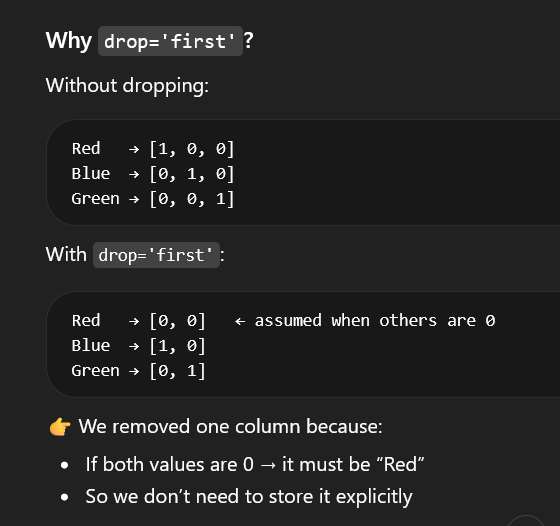

In [30]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Random Forest Classifier training

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,precision_score,roc_auc_score,roc_curve,recall_score,f1_score
from sklearn.tree import DecisionTreeClassifier

In [39]:
models = {
    "random_forest": RandomForestClassifier(),
    "decision_tree": DecisionTreeClassifier()
}

In [40]:
# checking how to access the above value for model.
print(list(models))
print(list(models.values()))
print(list(models.values())[0])

['random_forest', 'decision_tree']
[RandomForestClassifier(), DecisionTreeClassifier()]
RandomForestClassifier()


In [41]:
for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,Y_train) # training model
    #predicting
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # training set performance
    train_accuracy_score = accuracy_score(Y_train, y_train_pred)
    train_precision_score = precision_score(Y_train, y_train_pred)
    train_f1_score = f1_score(Y_train, y_train_pred, average='weighted')
    train_recall_score = recall_score(Y_train, y_train_pred)
    train_roc_auc_score = roc_auc_score (Y_train, y_train_pred)

    # test set performance
    test_accuracy_score = accuracy_score(Y_test, y_test_pred)
    test_precision_score = precision_score(Y_test, y_test_pred)
    test_f1_score = f1_score(Y_test, y_test_pred, average='weighted')
    test_recall_score = recall_score(Y_test, y_test_pred)
    test_roc_auc_score = roc_auc_score (Y_test, y_test_pred)
        
    print(list(models.keys())[i])    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(train_accuracy_score))
    print('- F1 score: {:.4f}'.format(train_f1_score))
    print('- Precision: {:.4f}'.format(train_precision_score))
    print('- Recall: {:.4f}'.format(train_recall_score))
    print('- Roc Auc Score: {:.4f}'.format(train_roc_auc_score)) 
    print('----------------------------------')    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(test_accuracy_score))
    print('- F1 score: {:.4f}'.format(test_f1_score))
    print('- Precision: {:.4f}'.format(test_precision_score))
    print('- Recall: {:.4f}'.format(test_recall_score))
    print('- Roc Auc Score: {:.4f}'.format(test_roc_auc_score))

    
    print('='*35)
    print('\n')

random_forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9264
- F1 score: 0.9209
- Precision: 0.9542
- Recall: 0.6545
- Roc Auc Score: 0.8234


decision_tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9182
- F1 score: 0.9172
- Precision: 0.8101
- Recall: 0.7592
- Roc Auc Score: 0.8580




In [45]:
# Hyperparameter training
rs_params = {
    "max_depth" : [5,8,15, None, 10],
    "max_features": [5,7,"auto",8],
    "min_samples_split": [2,8,15,20],
    "n_estimators": [100,200,500,1000]
}

In [46]:
randon_cv_models = [
    ("RF", RandomForestClassifier(), rs_params )
]

In [47]:
from sklearn.model_selection import RandomizedSearchCV
model_params = {}

for name,model,param in randon_cv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions=param,
                                n_iter = 100,
                                cv=3,
                                verbose=2,
                                n_jobs=1
                                )
    random.fit(X_train,Y_train)
    model_params[name] = random.best_params_

for k in model_params:
    print(f"------ Best parameters for {k} --------- ")
    print(model_params[k])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=15, max_features=7, min_samples_split=2, n_estimators=500; total time=   2.2s
[CV] END max_depth=15, max_features=7, min_samples_split=2, n_estimators=500; total time=   2.1s
[CV] END max_depth=15, max_features=7, min_samples_split=2, n_estimators=500; total time=   2.1s
[CV] END max_depth=10, max_features=auto, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=15, max_features=8, min_samples_split=2, n_estimators=1000; total time=   4.5s
[CV] END max_depth=15, max_features=8, min_samples_split=2, n_estimators=1000; total time=   4.5s
[CV] END max_depth=15, max_features=8, min_samples_split=2, n_estimators=1000; total time=   4.6s
[CV] END max_depth=None, max_features=8, min_samples

In [ ]:
# Plot Auc roc curve (optional) 


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>